# Environment Setup
Import libraries for data analysis, visualization, model training, and evaluation, and suppress warnings for cleaner output.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, precision_recall_curve, auc,
    mean_absolute_error, mean_squared_error, log_loss
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
Read the heart disease CSV file into a DataFrame and display the first few rows.

In [40]:
dataset = pd.read_csv('heart_disease.csv')
print(dataset.head())

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0                   No           

# Class Balance Check
Inspect the target distribution to identify whether class imbalance is present in the heart disease labels.

In [41]:
# Check class imbalance in target variable
print("\n=== CLASS IMBALANCE ANALYSIS ===")
target_column = dataset.columns[-1]  # Assuming last column is target
print(f"Target variable: {target_column}")
print("\nClass distribution:")
class_dist = dataset[target_column].value_counts()
print(class_dist)
print("\nClass distribution (%):")
print((class_dist / len(dataset) * 100).round(2))
print("\n⚠️ WARNING: Severe class imbalance detected!")
print("A model predicting all 'No' would get 80% accuracy but be useless.")
print("Solution: Using class_weight='balanced' to penalize misclassification of minority class.")


=== CLASS IMBALANCE ANALYSIS ===
Target variable: Heart Disease Status

Class distribution:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Class distribution (%):
Heart Disease Status
No     80.0
Yes    20.0
Name: count, dtype: float64

⚠️ WARNING: Severe class imbalance detected!
A model predicting all 'No' would get 80% accuracy but be useless.
Solution: Using class_weight='balanced' to penalize misclassification of minority class.


# Remove Duplicate Records
Drop any duplicate rows from the dataset to ensure the analysis uses unique samples.

In [42]:
# Check for and drop duplicates
print(f"Initial dataset shape: {dataset.shape}")
print(f"Duplicate rows: {dataset.duplicated().sum()}")

dataset = dataset.drop_duplicates()
print(f"Dataset shape after dropping duplicates: {dataset.shape}")
print(f"Rows removed: {dataset.shape[0] - dataset.shape[0]}")
dataset = dataset.reset_index(drop=True)

Initial dataset shape: (10000, 21)
Duplicate rows: 0
Dataset shape after dropping duplicates: (10000, 21)
Rows removed: 0


# Handle Missing Values
Inspect and impute missing values in both numerical and categorical columns to clean the dataset.

In [43]:
# Handle Missing Values
print("\n=== HANDLING MISSING VALUES ===\n")

# Show missing values summary
print("Missing values before imputation:")
missing_vals = dataset.isnull().sum()
missing_pct = (missing_vals / len(dataset) * 100).round(2)
missing_df = pd.DataFrame({'Column': missing_vals.index, 'Missing_Count': missing_vals.values, 'Missing_%': missing_pct.values})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string(index=False))

# Identify numerical and categorical columns
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Special handling for Alcohol Consumption (if exists)
alcohol_col = 'Alcohol Consumption' if 'Alcohol Consumption' in dataset.columns else None

if alcohol_col:
    print(f"\n📌 Special handling for '{alcohol_col}':")
    print(f"   Missing: {dataset[alcohol_col].isnull().sum()} ({(dataset[alcohol_col].isnull().sum()/len(dataset)*100):.1f}%)")
    print(f"   → Filling with 'Unknown' category (not guessing)")
    dataset[alcohol_col] = dataset[alcohol_col].fillna('Unknown')

# Fill missing values in other columns
for col in numerical_cols:
    if dataset[col].isnull().sum() > 0 and col != target_column:
        median_val = dataset[col].median()
        dataset[col] = dataset[col].fillna(median_val)
        print(f"   Filled {col} (numerical) with median: {median_val:.2f}")

for col in categorical_cols:
    if dataset[col].isnull().sum() > 0 and col != target_column:
        mode_val = dataset[col].mode()[0]
        dataset[col] = dataset[col].fillna(mode_val)
        print(f"   Filled {col} (categorical) with mode: {mode_val}")

# Verify no missing values remain
print(f"\n✅ Missing values after imputation: {dataset.isnull().sum().sum()}")
print("Data cleaning complete!")


=== HANDLING MISSING VALUES ===

Missing values before imputation:
              Column  Missing_Count  Missing_%
 Alcohol Consumption           2586      25.86
   Cholesterol Level             30       0.30
            Diabetes             30       0.30
   Sugar Consumption             30       0.30
                 Age             29       0.29
           CRP Level             26       0.26
  Triglyceride Level             26       0.26
 High Blood Pressure             26       0.26
High LDL Cholesterol             26       0.26
 Low HDL Cholesterol             25       0.25
         Sleep Hours             25       0.25
     Exercise Habits             25       0.25
             Smoking             25       0.25
        Stress Level             22       0.22
 Fasting Blood Sugar             22       0.22
                 BMI             22       0.22
Family Heart Disease             21       0.21
  Homocysteine Level             20       0.20
      Blood Pressure             19    

# Encode Categorical Data
Convert categorical columns into numeric values so machine learning models can use them.

In [44]:
# 3. Encode Categorical Columns
print("\n=== ENCODING CATEGORICAL COLUMNS ===")

# Binary Yes/No columns -> Label Encode (1/0)
binary_cols = [
    'Smoking', 
    'Family Heart Disease', 
    'Diabetes', 
    'High Blood Pressure', 
    'Low HDL Cholesterol', 
    'High LDL Cholesterol'
]
for col in binary_cols:
    dataset[col] = dataset[col].map({'Yes': 1, 'No': 0})
    print(f"Mapped binary column '{col}': Yes -> 1, No -> 0")

# Gender -> Label Encode (Male=1, Female=0)
dataset['Gender'] = dataset['Gender'].map({'Male': 1, 'Female': 0})
print("Mapped column 'Gender': Male -> 1, Female -> 0")

# Ordered Low/Medium/High columns -> Ordinal Encode (Low=0, Medium=1, High=2)
ordered_cols = ['Exercise Habits', 'Stress Level', 'Sugar Consumption']
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
for col in ordered_cols:
    dataset[col] = dataset[col].map(ordinal_map)
    print(f"Mapped ordered column '{col}': Low -> 0, Medium -> 1, High -> 2")

# Special handling for Alcohol Consumption (handling the 'Unknown' category introduced during imputation)
alcohol_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Unknown': -1}
dataset['Alcohol Consumption'] = dataset['Alcohol Consumption'].map(alcohol_map)
print("Mapped ordered column 'Alcohol Consumption' (with 'Unknown' -> -1): Low -> 0, Medium -> 1, High -> 2, Unknown -> -1")

# Verify the changes
print("\nEncoded dataset head:")
print(dataset[binary_cols + ['Gender', 'Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']].head())


=== ENCODING CATEGORICAL COLUMNS ===
Mapped binary column 'Smoking': Yes -> 1, No -> 0
Mapped binary column 'Family Heart Disease': Yes -> 1, No -> 0
Mapped binary column 'Diabetes': Yes -> 1, No -> 0
Mapped binary column 'High Blood Pressure': Yes -> 1, No -> 0
Mapped binary column 'Low HDL Cholesterol': Yes -> 1, No -> 0
Mapped binary column 'High LDL Cholesterol': Yes -> 1, No -> 0
Mapped column 'Gender': Male -> 1, Female -> 0
Mapped ordered column 'Exercise Habits': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Stress Level': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Sugar Consumption': Low -> 0, Medium -> 1, High -> 2
Mapped ordered column 'Alcohol Consumption' (with 'Unknown' -> -1): Low -> 0, Medium -> 1, High -> 2, Unknown -> -1

Encoded dataset head:
   Smoking  Family Heart Disease  Diabetes  High Blood Pressure  \
0        1                     1         0                    1   
1        0                     1         1                    0   
2  

# Encode Target Label
Convert the heart disease target variable to binary values for classification.

In [45]:
# 4. Encode Target Column
print("\n=== ENCODING TARGET COLUMN ===")

dataset['Heart Disease Status'] = dataset['Heart Disease Status'].map({'Yes': 1, 'No': 0})
print("Mapped target column 'Heart Disease Status': Yes -> 1, No -> 0")

# Verify the changes
print("\nTarget column value counts after encoding:")
print(dataset['Heart Disease Status'].value_counts())


=== ENCODING TARGET COLUMN ===
Mapped target column 'Heart Disease Status': Yes -> 1, No -> 0

Target column value counts after encoding:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


# Scale Numerical Features
Standardize the numerical predictors so they have mean 0 and variance 1 for modeling.

In [46]:
# 5. Scale Numerical Features
print("\n=== SCALING NUMERICAL FEATURES ===")

numerical_cols = [
    'Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
    'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 
    'CRP Level', 'Homocysteine Level'
]

# Initialize and apply StandardScaler
scaler = StandardScaler()
dataset[numerical_cols] = scaler.fit_transform(dataset[numerical_cols])

print(f"Applied StandardScaler to: {numerical_cols}")

# Verify the changes (means should be close to 0 and standard deviations close to 1)
print("\nScaled numerical features head:")
print(dataset[numerical_cols].head())


=== SCALING NUMERICAL FEATURES ===
Applied StandardScaler to: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Scaled numerical features head:
        Age  Blood Pressure  Cholesterol Level       BMI  Sleep Hours  \
0  0.369061        0.184661          -1.618712 -0.648537     0.366591   
1  1.084657       -0.214077           1.392213 -0.611996     1.001005   
2 -0.181398       -1.353328          -0.216679  0.123523    -1.456907   
3 -0.952040       -1.581178           1.553102 -0.785226    -0.994883   
4  0.589244        0.925175           0.380910 -1.363683     0.022624   

   Triglyceride Level  Fasting Blood Sugar  CRP Level  Homocysteine Level  
0            1.049660            -0.006024   1.268241           -0.015959  
1           -1.354031             1.564643   0.434477            1.584367  
2            1.636206            -1.194636   1.208400           -0.283696  
3           

# Preview Updated Dataset
Display the cleaned and transformed dataset to confirm the preprocessing changes.

In [47]:
dataset.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,0.369061,1,0.184661,-1.618712,2,1,1,0,-0.648537,1,...,0,2,1,0.366591,1,1.049660,-0.006024,1.268241,-0.015959,0
1,1.084657,0,-0.214077,1.392213,2,0,1,1,-0.611996,0,...,0,1,2,1.001005,1,-1.354031,1.564643,0.434477,1.584367,0
2,-0.181398,1,-1.353328,-0.216679,0,0,0,0,0.123523,0,...,1,0,0,-1.456907,0,1.636206,-1.194636,1.208400,-0.283696,0
3,-0.952040,0,-1.581178,1.553102,2,1,1,0,-0.785226,1,...,1,0,2,-0.994883,2,0.486115,-1.109735,1.162067,-1.503680,0
4,0.589244,1,0.925175,0.380910,0,1,1,1,-1.363683,1,...,0,0,2,0.022624,2,0.141087,1.437292,0.671158,-0.996158,0


# Outlier Visualization
Plot scaled numerical features with boxplots to inspect potential outliers after scaling.

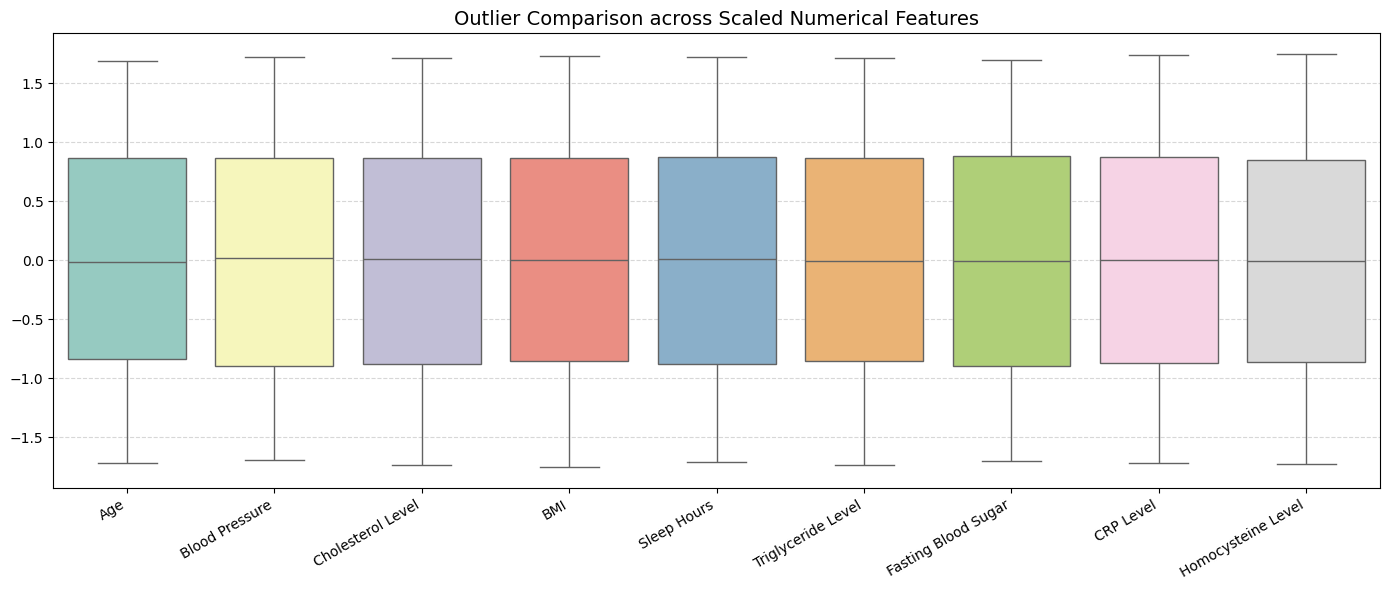

In [48]:
# Visualize Outliers - Combined Scaled Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=dataset[numerical_cols], palette='Set3')
plt.title('Outlier Comparison across Scaled Numerical Features', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlation Analysis
Visualize feature relationships and identify the most important predictors for heart disease.


=== GENERATING CORRELATION HEATMAP ===


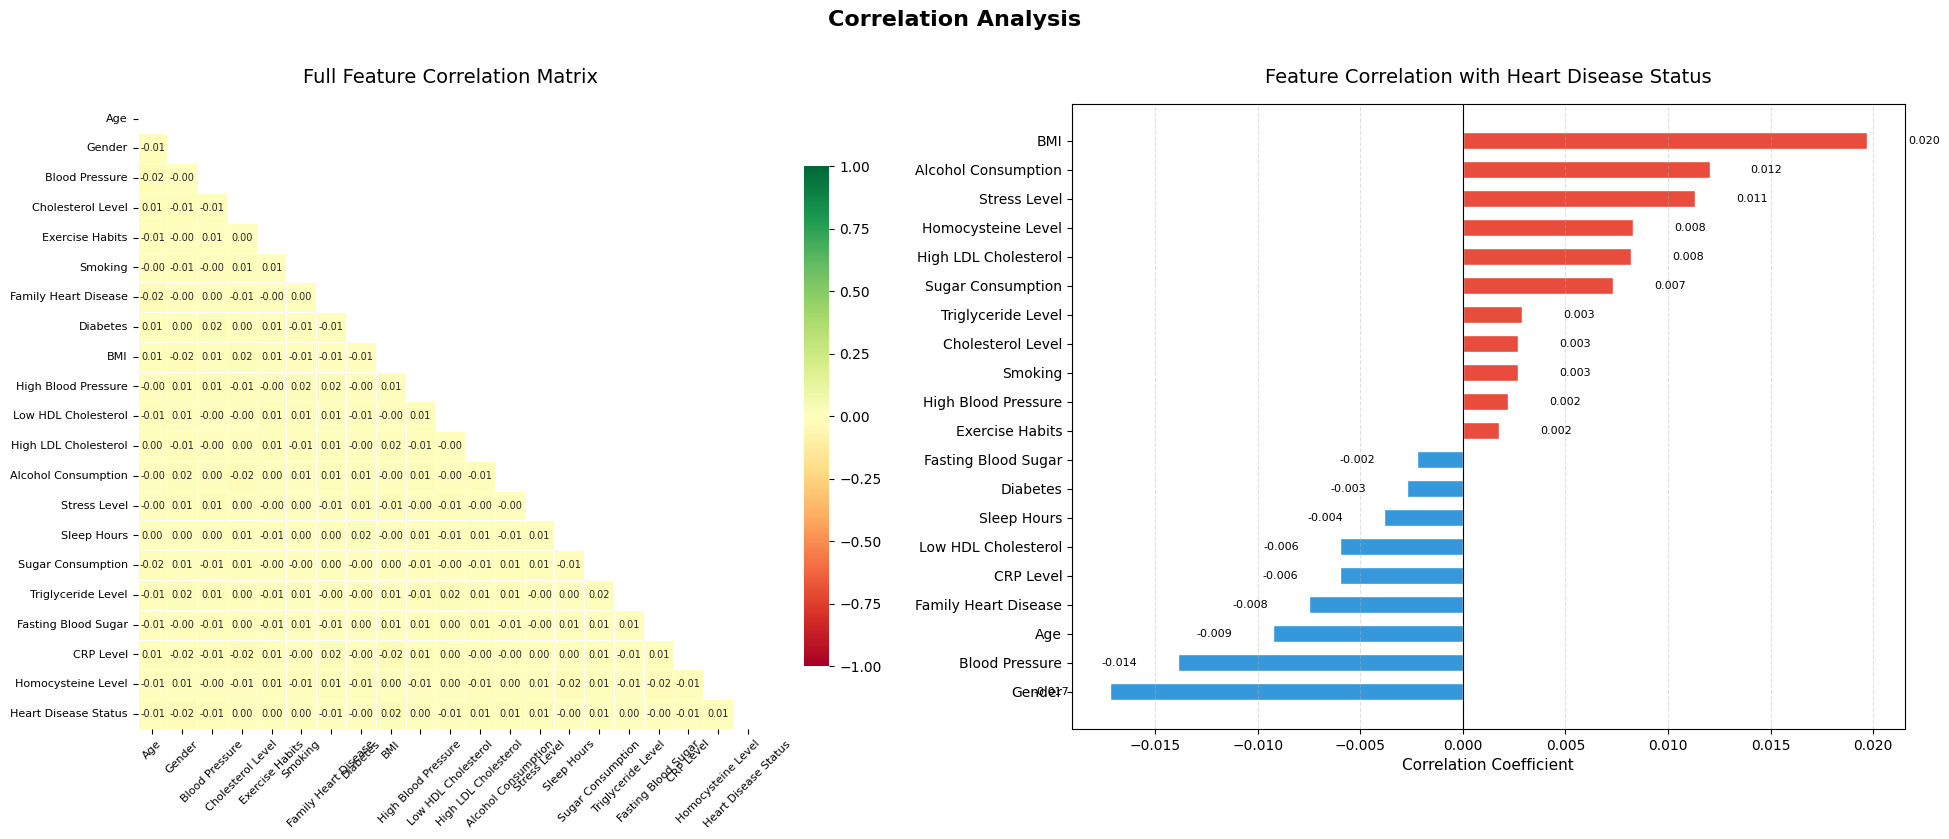


Top 5 features POSITIVELY correlated with Heart Disease:
BMI                     0.019682
Alcohol Consumption     0.012021
Stress Level            0.011332
Homocysteine Level      0.008302
High LDL Cholesterol    0.008201

Top 5 features NEGATIVELY correlated with Heart Disease:
CRP Level              -0.006009
Family Heart Disease   -0.007500
Age                    -0.009231
Blood Pressure         -0.013876
Gender                 -0.017200


In [49]:
# Correlation Heatmap
print("\n=== GENERATING CORRELATION HEATMAP ===")

corr_matrix = dataset.corr()

# Focus on correlation with target only (cleaner and more useful)
target_corr = corr_matrix['Heart Disease Status'].drop('Heart Disease Status').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Full Heatmap ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=axes[0],
    cmap='RdYlGn',
    vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title('Full Feature Correlation Matrix', fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# --- Plot 2: Target Correlation Bar Chart (more useful) ---
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("Feature Correlation with Heart Disease Status", fontsize=14, pad=15)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)

# Add value labels on bars
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                 f'{val:.3f}',
                 va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=8)

axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].invert_yaxis()

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print top positive and negative correlations with target
print("\nTop 5 features POSITIVELY correlated with Heart Disease:")
print(target_corr.head(5).to_string())
print("\nTop 5 features NEGATIVELY correlated with Heart Disease:")
print(target_corr.tail(5).to_string())

# Train/Test Split
Partition the dataset into training and test sets for model evaluation.

In [50]:
# 6. Train/Test Split
print("\n=== TRAIN/TEST SPLIT ===")

X = dataset.drop('Heart Disease Status', axis=1)
y = dataset['Heart Disease Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # ensures same 80/20 class ratio in both splits
)

print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(dataset)*100:.0f}%)")
print(f"Testing samples:  {len(X_test)} ({len(X_test)/len(dataset)*100:.0f}%)")
print(f"\nClass distribution in train set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())


=== TRAIN/TEST SPLIT ===
Total samples: 10000
Training samples: 8000 (80%)
Testing samples:  2000 (20%)

Class distribution in train set:
Heart Disease Status
0    6400
1    1600
Name: count, dtype: int64

Class distribution in test set:
Heart Disease Status
0    1600
1     400
Name: count, dtype: int64


# Apply SMOTE
Balance the training data by oversampling the minority class using SMOTE.

In [51]:
# 7. SMOTE - Apply on train set ONLY
print("\n=== APPLYING SMOTE ===")


print(f"Before SMOTE - Train class distribution:")
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Train class distribution:")
print(pd.Series(y_train_bal).value_counts())
print(f"\nTraining samples before SMOTE: {len(X_train)}")
print(f"Training samples after SMOTE:  {len(X_train_bal)}")
print(f"\n✅ Classes are now balanced for training.")
print(f"⚠️  Test set remains untouched (real world distribution preserved).")


=== APPLYING SMOTE ===
Before SMOTE - Train class distribution:
Heart Disease Status
0    6400
1    1600
Name: count, dtype: int64

After SMOTE - Train class distribution:
Heart Disease Status
0    6400
1    6400
Name: count, dtype: int64

Training samples before SMOTE: 8000
Training samples after SMOTE:  12800

✅ Classes are now balanced for training.
⚠️  Test set remains untouched (real world distribution preserved).


# Inspect Final Dataset
Show the final rows of the cleaned dataset to confirm the transformations.

In [52]:
dataset.tail()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
9995,-1.337362,0,-0.783702,0.403894,1,1,0,0,-1.633134,1,...,1,1,2,-0.089328,1,1.061161,0.545832,-0.895949,1.545730,1
9996,-0.621765,1,1.266950,-1.641696,1,0,0,0,0.441206,1,...,1,-1,2,0.717582,0,1.452192,-1.576690,-1.110638,-0.634532,1
9997,1.304840,1,0.127699,-0.561441,2,1,0,1,-0.345622,0,...,1,-1,0,-1.459007,0,-0.031426,-1.364438,-0.706752,-0.686230,1
9998,-1.447453,1,-0.441927,1.691007,0,1,0,1,0.934429,1,...,1,1,2,0.876667,1,-1.584050,1.394841,-0.059193,-0.134917,1
9999,-0.621765,0,-1.239403,-0.745314,1,1,1,1,-0.629536,0,...,1,2,1,-0.760725,2,-1.492042,1.225039,1.595523,-1.446588,1


# Logistic Regression Model
Train and evaluate a logistic regression classifier on the test set, then visualize results.


=== LOGISTIC REGRESSION ===

Accuracy  : 0.5825
Precision : 0.2000  (of those flagged as sick, how many actually are?)
Recall    : 0.3625  (of all sick people, how many did we catch?)
ROC-AUC   : 0.5103


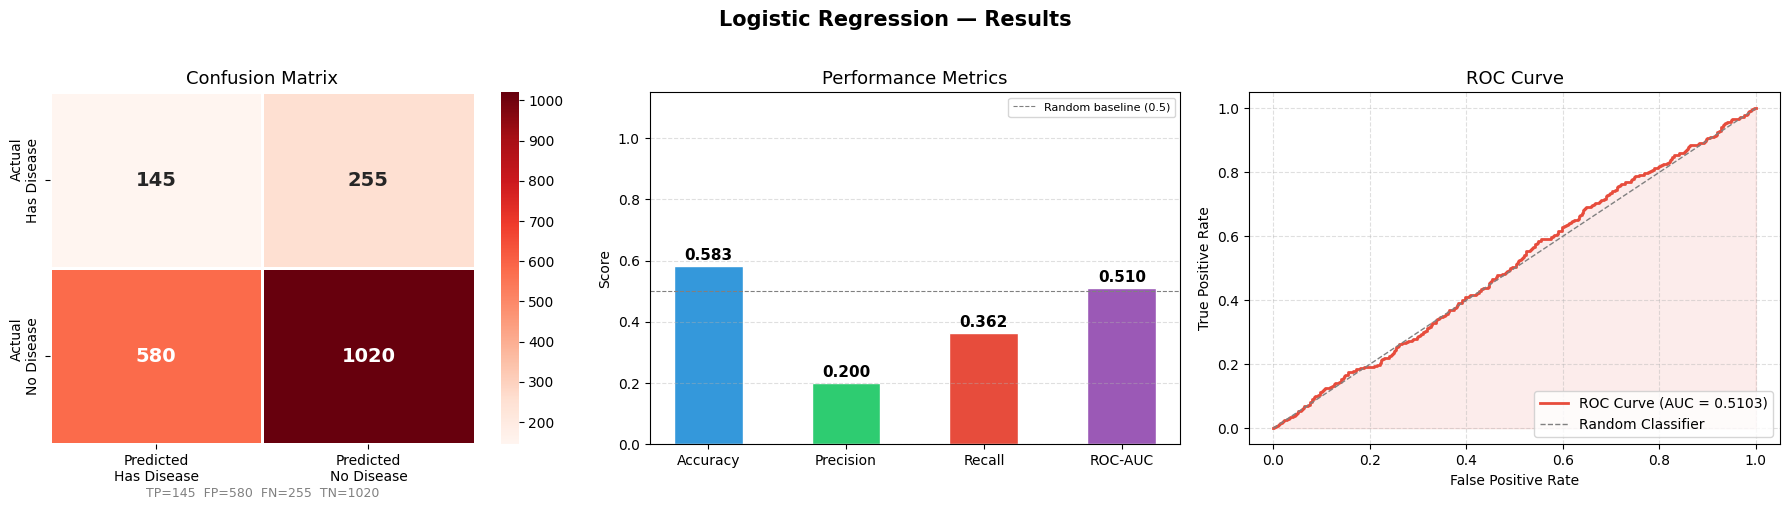


✅ Results stored for final model comparison.


In [53]:
# Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")
# Train
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_bal, y_train_bal)

# Predict
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────
accuracy  = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred, pos_label=1)
recall    = recall_score(y_test, lr_pred, pos_label=1)
auc       = roc_auc_score(y_test, lr_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

# ── Confusion Matrix (Positive=Has Disease FIRST) ────────
cm = confusion_matrix(y_test, lr_pred, labels=[1, 0])  # 1 first = Has Disease on top

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Logistic Regression — Results', fontsize=15, fontweight='bold', y=1.02)

# Plot 1 — Confusion Matrix
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Reds',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

# Annotate quadrants
tp = cm[0][0]  # Actual Disease, Predicted Disease
fp = cm[1][0]  # Actual No Disease, Predicted Disease
fn = cm[0][1]  # Actual Disease, Predicted No Disease
tn = cm[1][1]  # Actual No Disease, Predicted No Disease
axes[0].text(0.5, -0.15, f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# Plot 2 — Metrics Bar Chart
metrics       = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values        = [accuracy, precision, recall, auc]
bar_colors    = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Plot 3 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
axes[2].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Store for later comparison ────────────────────────────
lr_results = {
    'Model'     : 'Logistic Regression',
    'Accuracy'  : accuracy,
    'Precision' : precision,
    'Recall'    : recall,
    'ROC-AUC'   : auc
}
print("\n✅ Results stored for final model comparison.")

# K-Nearest Neighbors Model
Train and evaluate a KNN classifier, tune K, and compare performance metrics.


=== K-NEAREST NEIGHBORS ===
Finding optimal K...
Best K: 19 (Recall: 0.5625)

Accuracy  : 0.4690
Precision : 0.2023  (of those flagged as sick, how many actually are?)
Recall    : 0.5625  (of all sick people, how many did we catch?)
ROC-AUC   : 0.4938


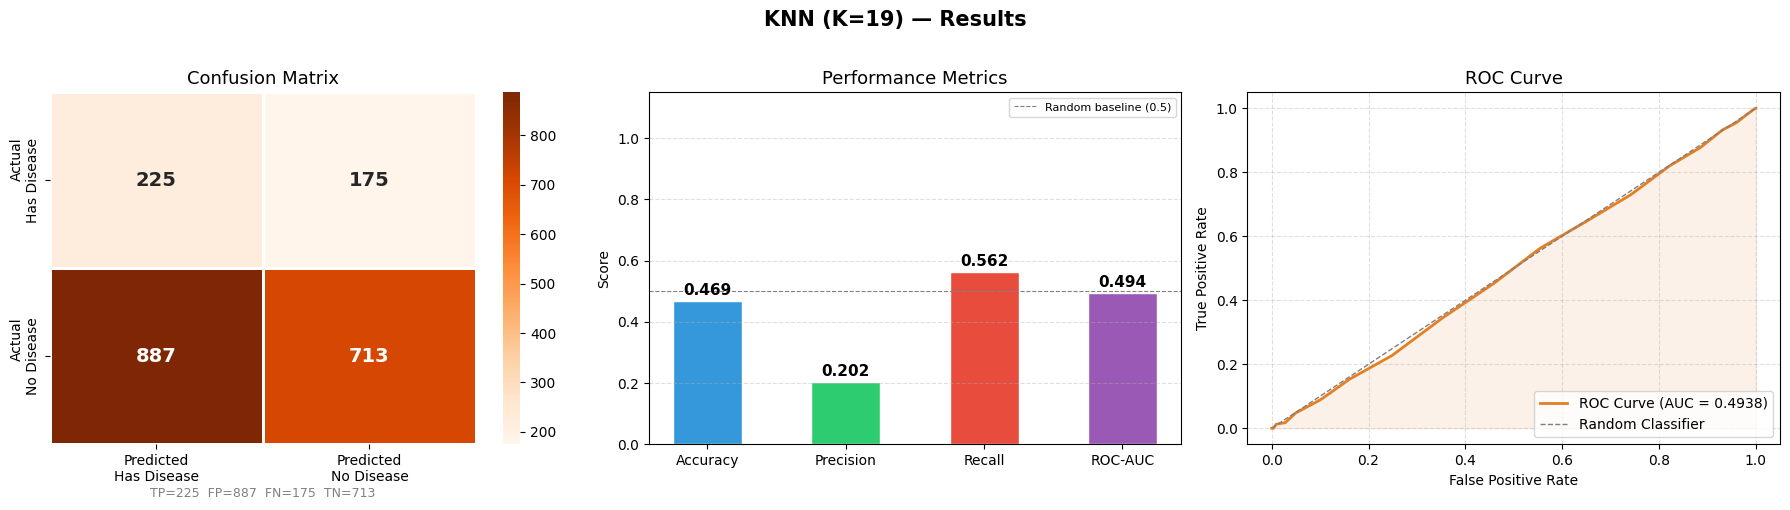

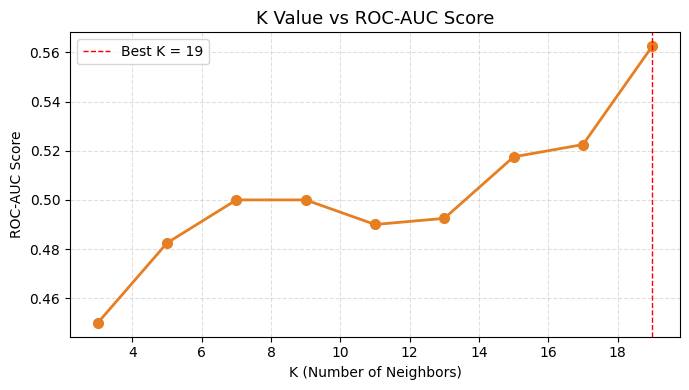


✅ Results stored for final model comparison.


In [54]:
# KNN Model
print("\n=== K-NEAREST NEIGHBORS ===")

# ── Find Optimal K ────────────────────────────────────────
print("Finding optimal K...")
k_scores = []
k_range = range(3, 21, 2)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)
    k_pred = knn.predict(X_test)
    k_scores.append(recall_score(y_test, k_pred, pos_label=1))  # recall on Has Disease

best_k = list(k_range)[k_scores.index(max(k_scores))]
print(f"Best K: {best_k} (Recall: {max(k_scores):.4f})")

# ── Train with Best K ─────────────────────────────────────
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_bal, y_train_bal)

# Predict
knn_pred  = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────
accuracy  = accuracy_score(y_test, knn_pred)
precision = precision_score(y_test, knn_pred, pos_label=1)
recall    = recall_score(y_test, knn_pred, pos_label=1)
auc       = roc_auc_score(y_test, knn_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

# ── Confusion Matrix (Positive=Has Disease FIRST) ─────────
cm = confusion_matrix(y_test, knn_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'KNN (K={best_k}) — Results', fontsize=15, fontweight='bold', y=1.02)

# Plot 1 — Confusion Matrix
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

tp = cm[0][0]
fp = cm[1][0]
fn = cm[0][1]
tn = cm[1][1]
axes[0].text(0.5, -0.15, f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# Plot 2 — Metrics Bar Chart
metrics    = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values     = [accuracy, precision, recall, auc]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Plot 3 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, knn_proba)
axes[2].plot(fpr, tpr, color='#e67e22', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Plot K vs AUC (bonus — shows why we picked this K)
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), k_scores, marker='o', color='#e67e22', linewidth=2, markersize=7)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1, label=f'Best K = {best_k}')
plt.title('K Value vs ROC-AUC Score', fontsize=13)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Store for later comparison ────────────────────────────
knn_results = {
    'Model'     : f'KNN (K={best_k})',
    'Accuracy'  : accuracy,
    'Precision' : precision,
    'Recall'    : recall,
    'ROC-AUC'   : auc
}
print("\n✅ Results stored for final model comparison.")

# Random Forest Model
Train and evaluate a Random Forest classifier and inspect feature importance.


=== RANDOM FOREST ===

Accuracy  : 0.6515
Precision : 0.2071  (of those flagged as sick, how many actually are?)
Recall    : 0.2625  (of all sick people, how many did we catch?)
ROC-AUC   : 0.5079


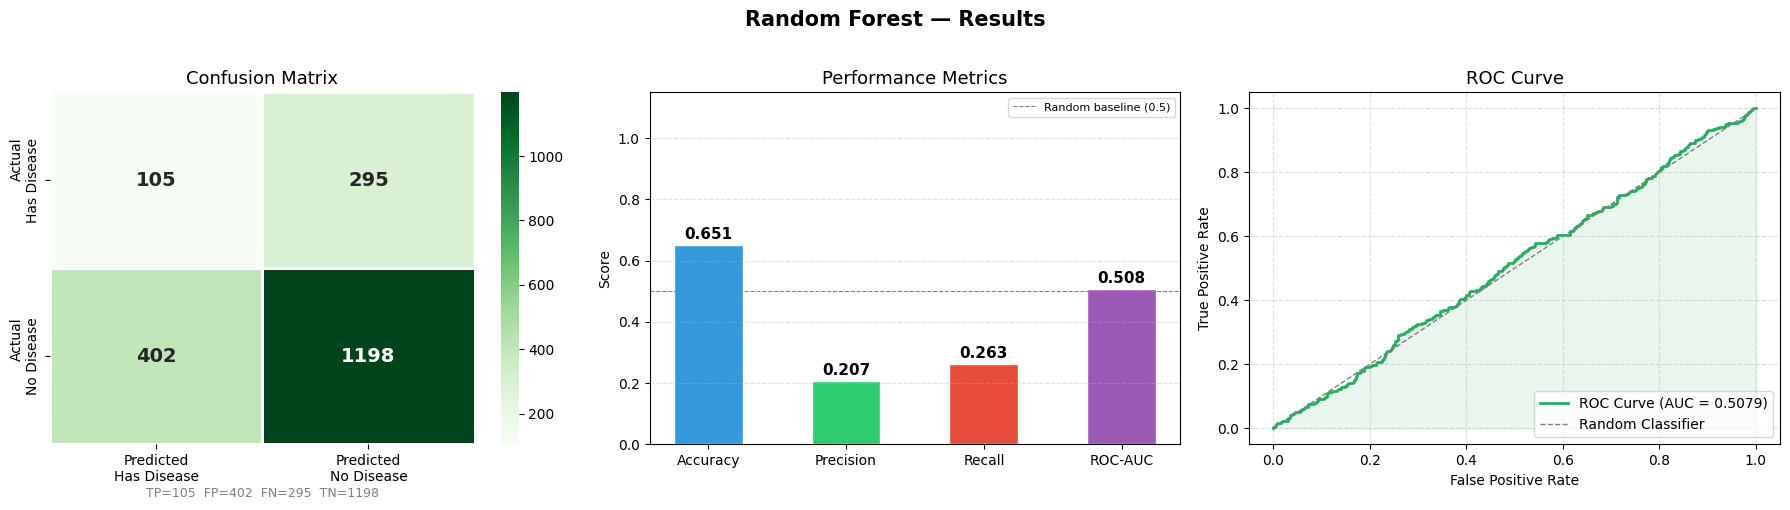

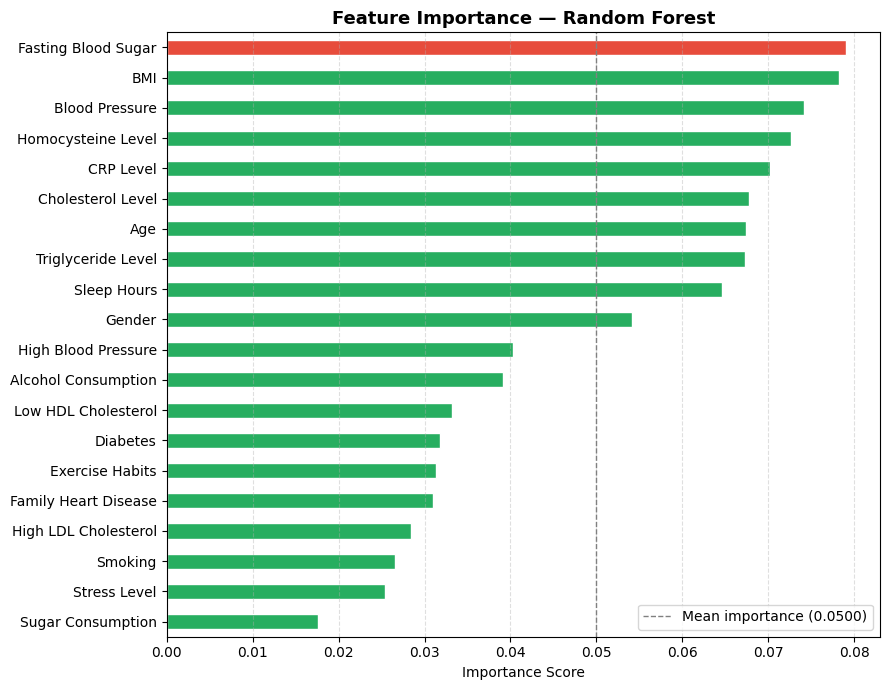


Top 5 most important features:
Fasting Blood Sugar    0.079032
BMI                    0.078209
Blood Pressure         0.074158
Homocysteine Level     0.072659
CRP Level              0.070191

✅ Results stored for final model comparison.


In [55]:
# Random Forest
print("\n=== RANDOM FOREST ===")

# ── Train ─────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)

# ── Predict ───────────────────────────────────────────────
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────
accuracy  = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred, pos_label=1)
recall    = recall_score(y_test, rf_pred, pos_label=1)
auc       = roc_auc_score(y_test, rf_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

# ── Confusion Matrix (Has Disease FIRST) ──────────────────
cm = confusion_matrix(y_test, rf_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Results', fontsize=15, fontweight='bold', y=1.02)

# Plot 1 — Confusion Matrix
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

tp = cm[0][0]
fp = cm[1][0]
fn = cm[0][1]
tn = cm[1][1]
axes[0].text(0.5, -0.15, f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# Plot 2 — Metrics Bar Chart
metrics    = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values     = [accuracy, precision, recall, auc]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Plot 3 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_proba)
axes[2].plot(fpr, tpr, color='#27ae60', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#27ae60')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Feature Importance Plot (bonus — unique to Random Forest) ──
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#e74c3c' if v == feature_importance.max() else '#27ae60' 
          for v in feature_importance.values]
feature_importance.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=feature_importance.mean(), color='gray', linestyle='--', 
            linewidth=1, label=f'Mean importance ({feature_importance.mean():.4f})')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features:")
print(feature_importance.sort_values(ascending=False).head(5).to_string())

# ── Store for later comparison ────────────────────────────
rf_results = {
    'Model'     : 'Random Forest',
    'Accuracy'  : accuracy,
    'Precision' : precision,
    'Recall'    : recall,
    'ROC-AUC'   : auc
}
print("\n✅ Results stored for final model comparison.")

# Final Notes
Reserved space for additional code, experiments, or conclusions after model evaluation.

# Support Vector Machine Model
Train and evaluate an SVM classifier on the balanced training data and compare its performance with the other models.


=== SUPPORT VECTOR MACHINE ===

Accuracy  : 0.6370
Precision : 0.2015  (of those flagged as sick, how many actually are?)
Recall    : 0.2750  (of all sick people, how many did we catch?)
ROC-AUC   : 0.5142


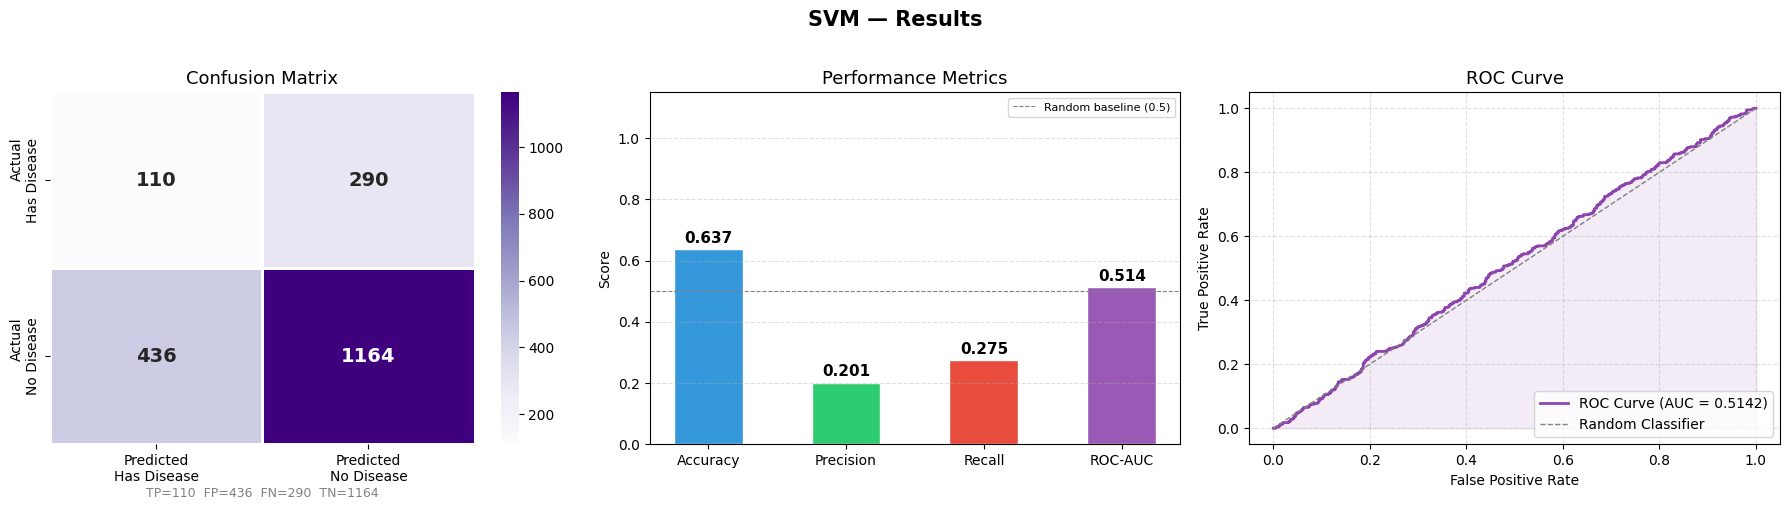


✅ SVM results stored for final model comparison.


In [56]:
# Support Vector Machine
print("\n=== SUPPORT VECTOR MACHINE ===")

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_bal, y_train_bal)

svm_pred = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, svm_pred)
precision = precision_score(y_test, svm_pred, pos_label=1)
recall = recall_score(y_test, svm_pred, pos_label=1)
auc = roc_auc_score(y_test, svm_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

cm = confusion_matrix(y_test, svm_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SVM — Results', fontsize=15, fontweight='bold', y=1.02)

sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Purples',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

# Annotate quadrants
TP = cm[0][0]
FP = cm[1][0]
FN = cm[0][1]
TN = cm[1][1]
axes[0].text(0.5, -0.15, f'TP={TP}  FP={FP}  FN={FN}  TN={TN}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values = [accuracy, precision, recall, auc]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, svm_proba)
axes[2].plot(fpr, tpr, color='#8e44ad', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#8e44ad')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

svm_results = {
    'Model': 'SVM',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'ROC-AUC': auc
}
print("\n✅ SVM results stored for final model comparison.")

# XGBoost Model
Train and evaluate an XGBoost classifier on the balanced training data and compare its performance with the other models.


=== XGBOOST ===

Accuracy  : 0.6495
Precision : 0.2111  (of those flagged as sick, how many actually are?)
Recall    : 0.2750  (of all sick people, how many did we catch?)
ROC-AUC   : 0.4941


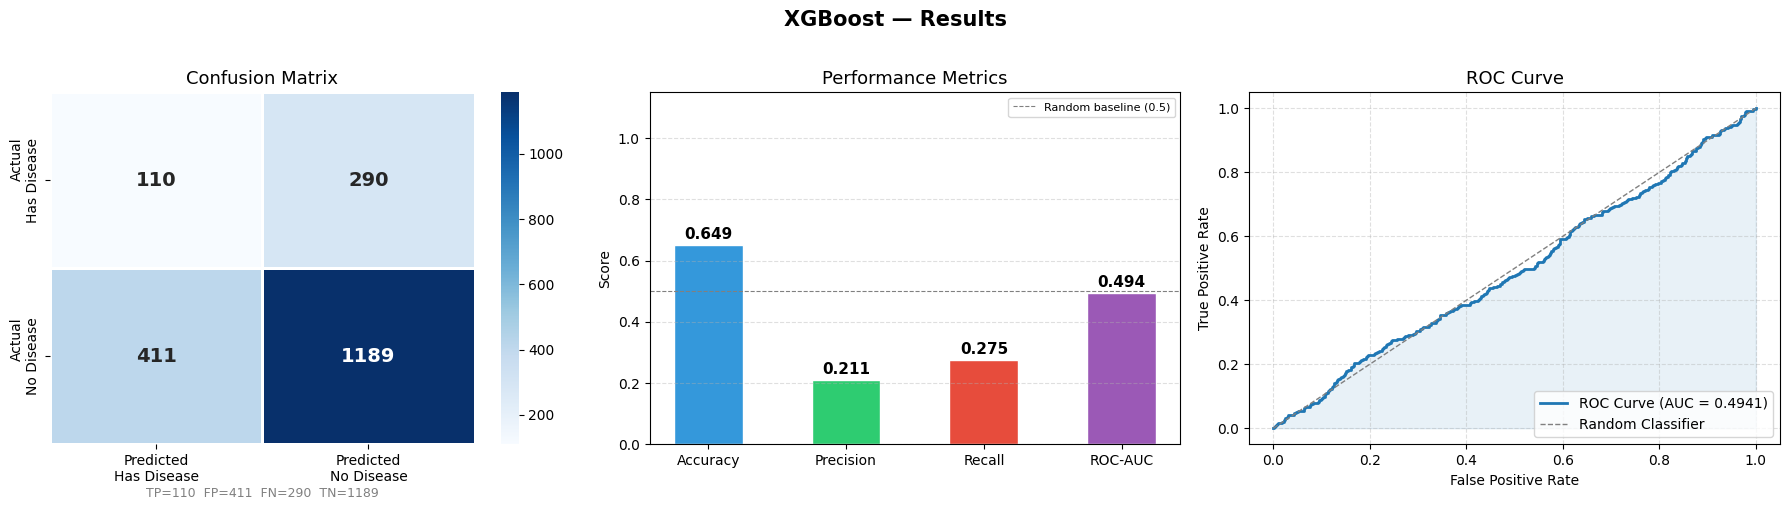


✅ XGBoost results stored for final model comparison.


In [57]:
# XGBoost
print("\n=== XGBOOST ===")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)
xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, xgb_pred)
precision = precision_score(y_test, xgb_pred, pos_label=1)
recall = recall_score(y_test, xgb_pred, pos_label=1)
auc = roc_auc_score(y_test, xgb_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

cm = confusion_matrix(y_test, xgb_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost — Results', fontsize=15, fontweight='bold', y=1.02)

sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

TP = cm[0][0]
FP = cm[1][0]
FN = cm[0][1]
TN = cm[1][1]
axes[0].text(0.5, -0.15, f'TP={TP}  FP={FP}  FN={FN}  TN={TN}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values = [accuracy, precision, recall, auc]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, xgb_proba)
axes[2].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#1f77b4')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'ROC-AUC': auc
}
print("\n✅ XGBoost results stored for final model comparison.")

# Naive Bayes Model
Train and evaluate a Gaussian Naive Bayes classifier on the balanced training data and compare its performance with the other models.


=== NAIVE BAYES ===

Accuracy  : 0.5955
Precision : 0.2015  (of those flagged as sick, how many actually are?)
Recall    : 0.3450  (of all sick people, how many did we catch?)
ROC-AUC   : 0.5067


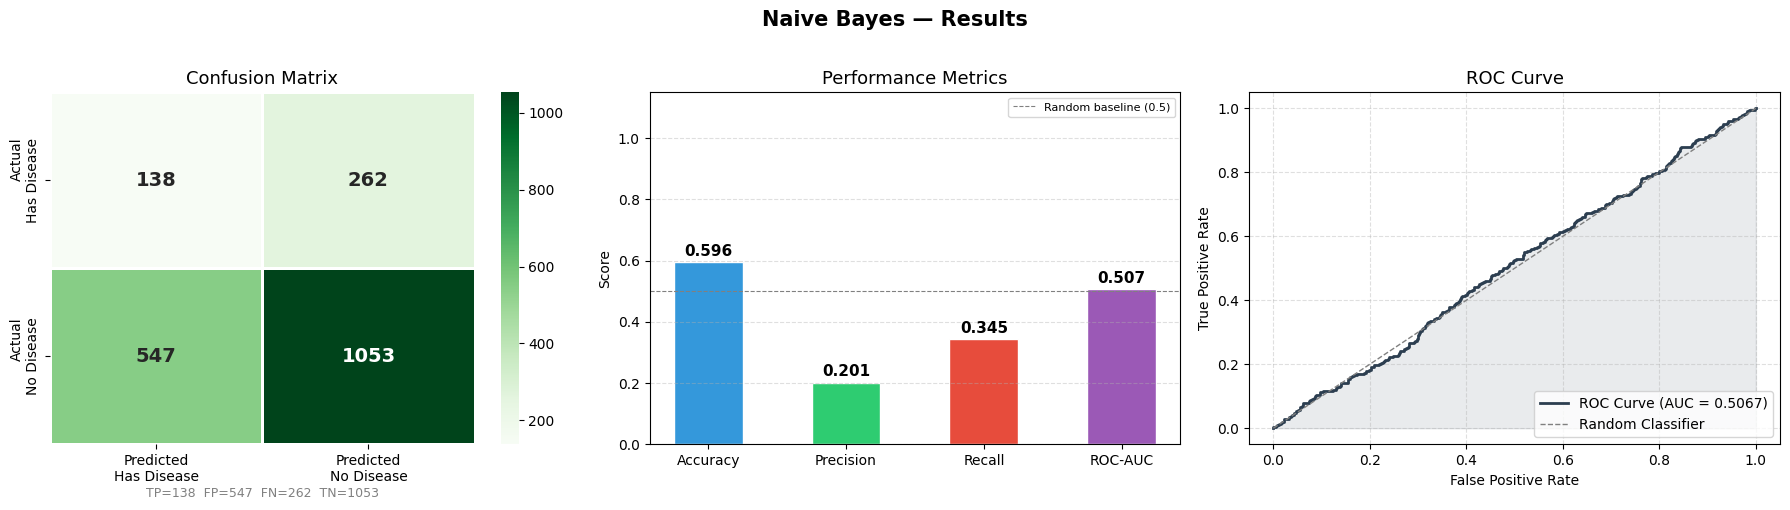


✅ Naive Bayes results stored for final model comparison.


In [58]:
# Naive Bayes
print("\n=== NAIVE BAYES ===")

nb_model = GaussianNB()
nb_model.fit(X_train_bal, y_train_bal)

nb_pred = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, nb_pred)
precision = precision_score(y_test, nb_pred, pos_label=1)
recall = recall_score(y_test, nb_pred, pos_label=1)
auc = roc_auc_score(y_test, nb_proba)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (of those flagged as sick, how many actually are?)")
print(f"Recall    : {recall:.4f}  (of all sick people, how many did we catch?)")
print(f"ROC-AUC   : {auc:.4f}")

cm = confusion_matrix(y_test, nb_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Naive Bayes — Results', fontsize=15, fontweight='bold', y=1.02)

sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted\nHas Disease', 'Predicted\nNo Disease'],
    yticklabels=['Actual\nHas Disease', 'Actual\nNo Disease'],
    ax=axes[0],
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title('Confusion Matrix', fontsize=13)

TP = cm[0][0]
FP = cm[1][0]
FN = cm[0][1]
TN = cm[1][1]
axes[0].text(0.5, -0.15, f'TP={TP}  FP={FP}  FN={FN}  TN={TN}',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
values = [accuracy, precision, recall, auc]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, nb_proba)
axes[2].plot(fpr, tpr, color='#2c3e50', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#2c3e50')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].legend(loc='lower right')
axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

nb_results = {
    'Model': 'Naive Bayes',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'ROC-AUC': auc
}
print("\n✅ Naive Bayes results stored for final model comparison.")

# Model Comparison
Summarize and compare performance metrics across all trained models.

Model comparison summary:


,Accuracy,Precision,Recall,ROC-AUC
Model,,,,
Logistic Regression,0.5825,0.200000,0.3625,0.510313
KNN (K=19),0.4690,0.202338,0.5625,0.493777
Random Forest,0.6515,0.207101,0.2625,0.507861
SVM,0.6370,0.201465,0.2750,0.514208
XGBoost,0.6495,0.211132,0.2750,0.494098
Naive Bayes,0.5955,0.201460,0.3450,0.506722


<Figure size 1200x600 with 0 Axes>

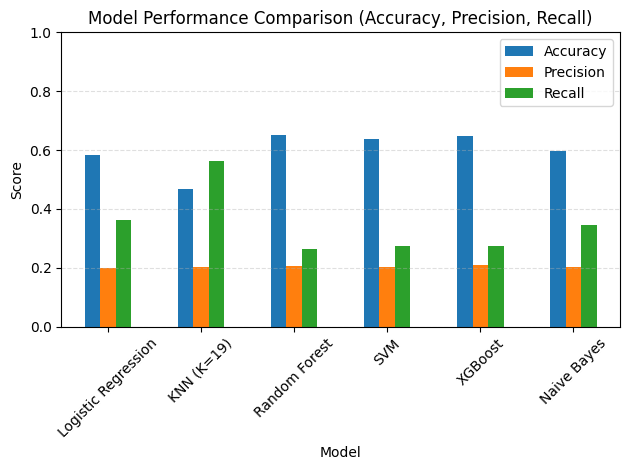

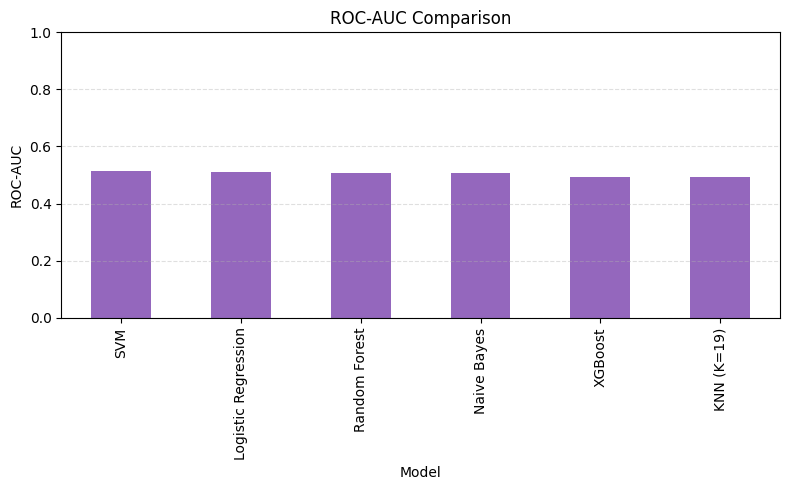

Best models by metric:
- Best accuracy: Random Forest (0.6515)
- Best precision: XGBoost (0.2111)
- Best recall: KNN (K=19) (0.5625)
- Best ROC-AUC: SVM (0.5142)


In [59]:
# Compare all model results
comparison_df = pd.DataFrame([lr_results, knn_results, rf_results, svm_results, xgb_results, nb_results])
comparison_df = comparison_df.set_index('Model')

print("Model comparison summary:")
display(comparison_df)

# Plot overall comparison
plt.figure(figsize=(12, 6))
comparison_df[['Accuracy', 'Precision', 'Recall']].plot(kind='bar', rot=45)
plt.title('Model Performance Comparison (Accuracy, Precision, Recall)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
comparison_df['ROC-AUC'].sort_values(ascending=False).plot(kind='bar', color='tab:purple')
plt.title('ROC-AUC Comparison')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Best models by metric:")
print(f"- Best accuracy: {comparison_df['Accuracy'].idxmax()} ({comparison_df['Accuracy'].max():.4f})")
print(f"- Best precision: {comparison_df['Precision'].idxmax()} ({comparison_df['Precision'].max():.4f})")
print(f"- Best recall: {comparison_df['Recall'].idxmax()} ({comparison_df['Recall'].max():.4f})")
print(f"- Best ROC-AUC: {comparison_df['ROC-AUC'].idxmax()} ({comparison_df['ROC-AUC'].max():.4f})")

# Final Classifier Selection
Select the model with the highest recall score from the comparison table and use it as the final classifier for future predictions.

In [61]:
# Select the model with the highest recall as the final classifier
print("\n=== FINAL CLASSIFIER SELECTION ===")

best_recall_model_name = comparison_df['Recall'].idxmax()
best_recall_score = comparison_df.loc[best_recall_model_name, 'Recall']

model_candidates = [
    ('Logistic Regression', lr_model, lr_pred, lr_proba),
    (knn_results['Model'], knn_model, knn_pred, knn_proba),
    ('Random Forest', rf_model, rf_pred, rf_proba),
    ('SVM', svm_model, svm_pred, svm_proba),
    ('XGBoost', xgb_model, xgb_pred, xgb_proba),
    ('Naive Bayes', nb_model, nb_pred, nb_proba),
]

selected_entry = next(entry for entry in model_candidates if entry[0] == best_recall_model_name)
final_model_name, final_model, final_pred, final_proba = selected_entry

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, pos_label=1)
final_recall = recall_score(y_test, final_pred, pos_label=1)
final_auc = roc_auc_score(y_test, final_proba)

final_classifier = final_model
final_predictions = final_pred
final_probabilities = final_proba

print(f"Selected final classifier: {final_model_name}")
print(f"Highest recall score: {best_recall_score:.4f}")
print(f"Final accuracy: {final_accuracy:.4f}")
print(f"Final precision: {final_precision:.4f}")
print(f"Final recall: {final_recall:.4f}")
print(f"Final ROC-AUC: {final_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, final_predictions, target_names=['No Disease', 'Has Disease']))


=== FINAL CLASSIFIER SELECTION ===
Selected final classifier: KNN (K=19)
Highest recall score: 0.5625
Final accuracy: 0.4690
Final precision: 0.2023
Final recall: 0.5625
Final ROC-AUC: 0.4938

Classification report:
              precision    recall  f1-score   support

  No Disease       0.80      0.45      0.57      1600
 Has Disease       0.20      0.56      0.30       400

    accuracy                           0.47      2000
   macro avg       0.50      0.50      0.44      2000
weighted avg       0.68      0.47      0.52      2000



In [ ]:
import joblib
import json

# Save the final classifier
joblib.dump(final_classifier, 'heart_disease_model.pkl')
print("✓ Model saved: heart_disease_model.pkl")

# Save the scaler
joblib.dump(scaler, 'heart_disease_scaler.pkl')
print("✓ Scaler saved: heart_disease_scaler.pkl")

# Save feature names
feature_names = X_train.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("✓ Features saved: feature_names.json")

# Save model metadata
model_info = {
    'model_name': final_model_name,
    'accuracy': float(final_accuracy),
    'precision': float(final_precision),
    'recall': float(final_recall),
    'auc': float(final_auc),
    'feature_count': len(feature_names)
}
with open('model_metadata.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("✓ Metadata saved: model_metadata.json")
print("\n✅ All model files exported successfully!")